In [1]:
!pip install yfinance -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [3]:
from google.colab import files
uploaded=files.upload()

Saving stock value.csv to stock value.csv


In [4]:
ticker = "AAPL"
data = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=False
)
print(data.head())
print("\nDataset Shape:", data.shape)

[*********************100%***********************]  1 of 1 completed

Price       Adj Close      Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                                        
2015-01-02  24.171761  27.332500  27.860001  26.837500  27.847500  212818400
2015-01-05  23.490803  26.562500  27.162500  26.352501  27.072500  257142000
2015-01-06  23.493023  26.565001  26.857500  26.157499  26.635000  263188400
2015-01-07  23.822432  26.937500  27.049999  26.674999  26.799999  160423600
2015-01-08  24.737741  27.972500  28.037500  27.174999  27.307501  237458000

Dataset Shape: (2516, 6)


In [7]:
close_data = data[['Close']].copy()
if isinstance(close_data.columns, pd.MultiIndex):
    close_data = close_data.xs('Close', axis=1, level=0)
close_data.columns = ['Close']
print(close_data.head())
print("\nTotal Records:", len(close_data))

                Close
Date                 
2015-01-02  27.332500
2015-01-05  26.562500
2015-01-06  26.565001
2015-01-07  26.937500
2015-01-08  27.972500

Total Records: 2516


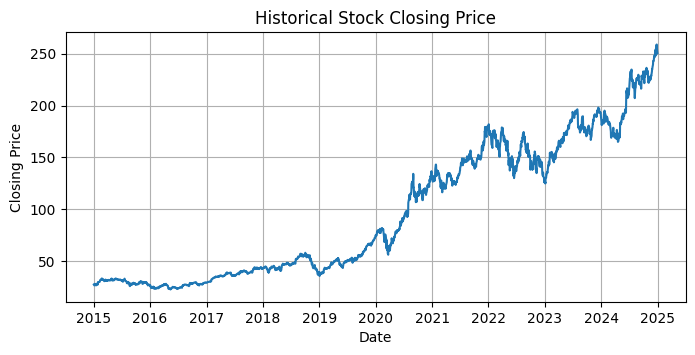

In [26]:
plt.figure(figsize=(8,3.5))
plt.plot(close_data.index, close_data['Close'])
plt.title("Historical Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

In [9]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(
    close_data[['Close']]
)
print("First 5 Scaled Values:")
print(scaled_data[:5])

First 5 Scaled Values:
[[0.02007952]
 [0.01682281]
 [0.01683339]
 [0.01840887]
 [0.02278639]]


In [10]:
sequence_length = 60
X = []
y = []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])
X = np.array(X)
y = np.array(y)
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)
print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (2456, 60, 1)
Y Shape: (2456,)


In [11]:
train_size = int(len(X) * 0.8)
X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1964
Testing Samples: 492


In [12]:
model = Sequential()
model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)
model.add(Dropout(0.2))
model.add(
    LSTM(
        50,
        return_sequences=False
    )
)
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.0059 - val_loss: 0.0015
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0013 - val_loss: 0.0028
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 9.3102e-04 - val_loss: 6.3770e-04
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 7.7949e-04 - val_loss: 0.0021
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 6.7701e-04 - val_loss: 9.6409e-04
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 7.1175e-04 - val_loss: 9.3588e-04
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 6.7365e-04 - val_loss: 6.4581e-04
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 5.8478e-04 - val_loss: 0.0026
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 5.8966e-04 - val_loss: 5.6669e-04
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 6.2822e-04 - val_loss: 0.0015
Epoch 12/20

In [14]:
predicted_scaled = model.predict(X_test)
predicted_prices = scaler.inverse_transform(
    predicted_scaled
)
actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)
print("First 10 Predicted Prices:")
print(predicted_prices[:10])
print("\nFirst 10 Actual Prices:")
print(actual_prices[:10])

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
First 10 Predicted Prices:
[[128.87744]
 [129.85832]
 [130.70134]
 [131.59871]
 [132.71503]
 [133.98235]
 [135.17422]
 [136.38687]
 [137.66414]
 [138.62329]]

First 10 Actual Prices:
[[135.21000671]
 [135.27000427]
 [137.86999512]
 [141.11000061]
 [142.52999878]
 [141.86000061]
 [143.96000671]
 [145.92999268]
 [143.        ]
 [144.28999329]]


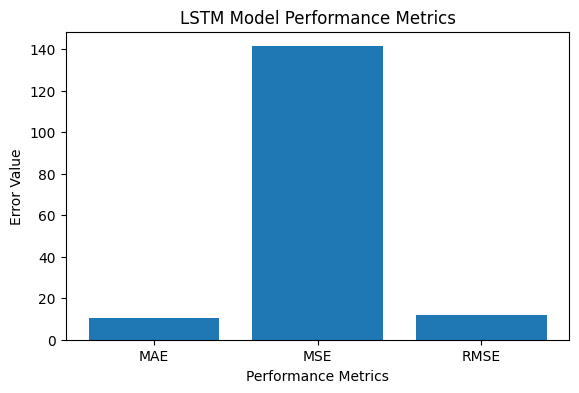

In [27]:
metrics = ["MAE", "MSE", "RMSE"]
values = [mae, mse, rmse]
plt.figure(figsize=(6.5, 4))
plt.bar(metrics, values)
plt.xlabel("Performance Metrics")
plt.ylabel("Error Value")
plt.title("LSTM Model Performance Metrics")
plt.show()

In [20]:
last_60_days = scaled_data[-60:]
X_future = last_60_days.reshape(
    1, 60, 1
)
next_day_scaled = model.predict(X_future)
next_day_price = scaler.inverse_transform(
    next_day_scaled
)
latest_price = float(
    close_data['Close'].iloc[-1]
)
predicted_next_price = float(
    next_day_price[0][0]
)

print("Latest Closing Price:", latest_price)
print(
    "Predicted Next Day Closing Price:",
    predicted_next_price
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Latest Closing Price: 250.4199981689453
Predicted Next Day Closing Price: 235.37416076660156


In [22]:
print("=" * 45)
print("       STOCK VALUE PREDICTION USING LSTM")
print("=" * 45)
print("Stock:", ticker)
print("Latest Closing Price:",
      round(latest_price, 2))
print("Predicted Next Day Price:",
      round(predicted_next_price, 2))
print("MAE:",
      round(mae, 4))
print("MSE:",
      round(mse, 4))
print("RMSE:",
      round(rmse, 4))
print("=" * 45)

       STOCK VALUE PREDICTION USING LSTM
Stock: AAPL
Latest Closing Price: 250.42
Predicted Next Day Price: 235.37
MAE: 10.4145
MSE: 141.2422
RMSE: 11.8845


Confusion Matrix:
[[215   3]
 [272   2]]


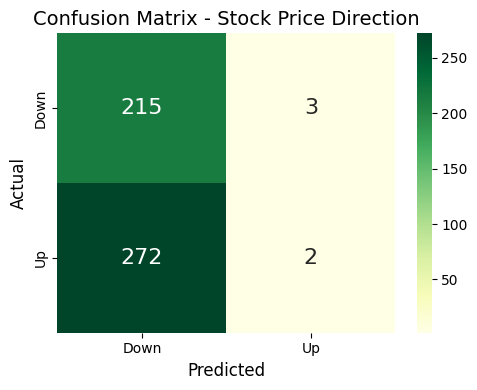

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
previous_prices = close_data['Close'].values[
    sequence_length + train_size - 1 :
    sequence_length + len(X) - 1
]

actual_direction = (
    actual_prices.flatten() > previous_prices
).astype(int)

predicted_direction = (
    predicted_prices.flatten() > previous_prices
).astype(int)

cm = confusion_matrix(
    actual_direction,
    predicted_direction
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGn',
    xticklabels=['Down', 'Up'],
    yticklabels=['Down', 'Up'],
    annot_kws={"size": 16}
)

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix - Stock Price Direction", fontsize=14)

plt.tight_layout()
plt.show()

In [29]:
last60 = scaled_data[-60:].reshape(1, 60, 1)

pred = model.predict(last60, verbose=0)
pred_price = scaler.inverse_transform(pred)[0][0]

latest = close_data['Close'].iloc[-1]

print("Latest Price:", round(float(latest), 2))
print("Predicted Price:", round(float(pred_price), 2))

if pred_price > latest:
    print("Direction: UP")
else:
    print("Direction: DOWN")

Latest Price: 250.42
Predicted Price: 235.37
Direction: DOWN
